In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix 
from sklearn.datasets import load_iris  

In [2]:
iris = load_iris()
data = pd.DataFrame(data = iris.data , columns = iris.feature_names)
data['target'] = iris.target
print(data.head())
print(data.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
(150, 5)


In [3]:
X = data.drop(columns='target')
y = data['target']
print(X.shape)
print(y.shape)

(150, 4)
(150,)


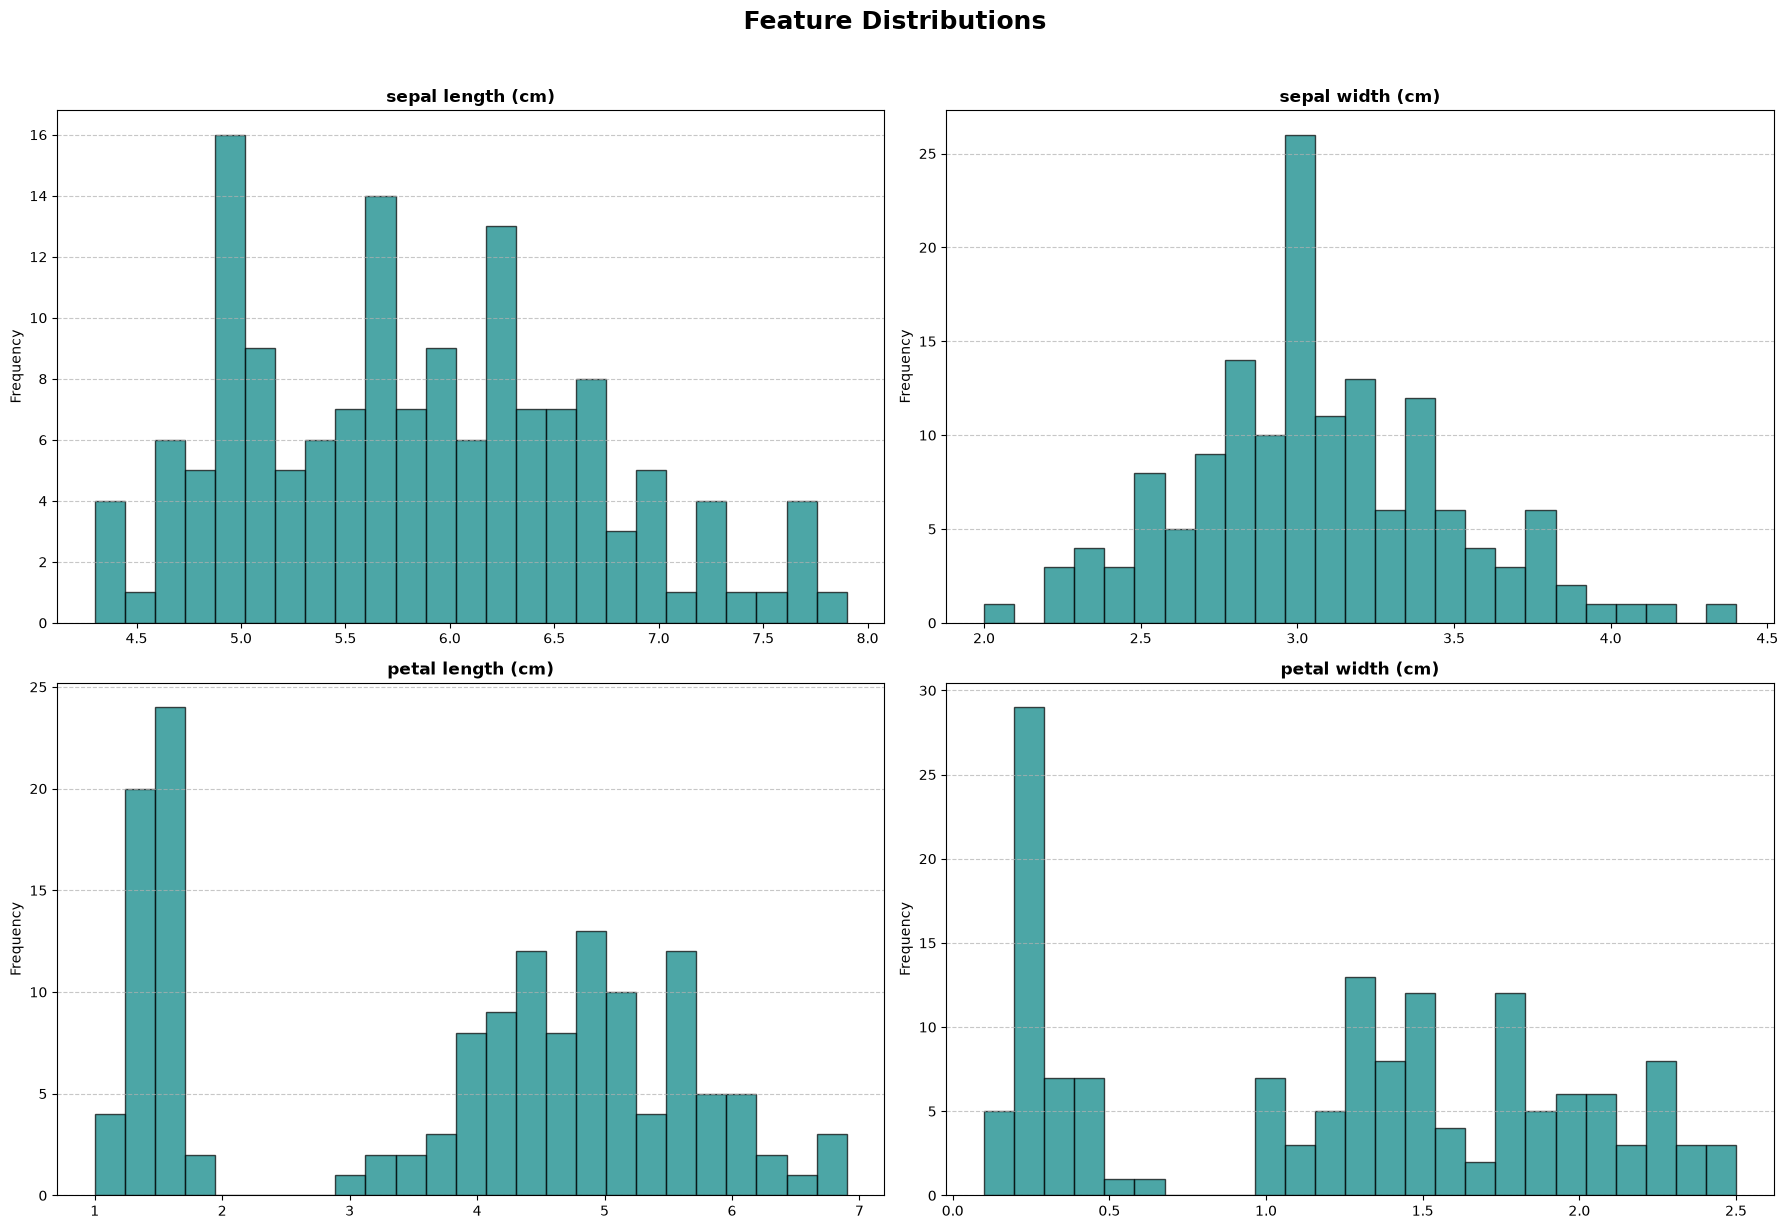

In [4]:
num_features = X.shape[1]
num_rows = math.ceil(num_features/2)
ax = X.hist(layout = (num_rows,2),figsize=(18,6*num_rows),bins = 25,color = 'teal',edgecolor = 'black',alpha = 0.7)
for ax in ax.flatten():
    ax.set_title(ax.get_title(),fontsize = 12 , fontweight = 'bold')
    ax.set_ylabel("Frequency", fontsize = 10)
    ax.grid(axis = 'y' , linestyle = '--', alpha = 0.7)
    ax.grid(axis = 'x', visible = False)
plt.suptitle("Feature Distributions", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()    


In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state = 42)


In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

rfc = RandomForestClassifier(random_state=42)


stratifiedKFold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cvScores = cross_val_score(
    rfc,
    X_train,
    y_train,
    cv=stratifiedKFold,
    scoring="accuracy"
)

meanAccuracy = cvScores.mean()
print(meanAccuracy)

0.95


In [ ]:
# Grid Search Tuning 
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50,100,200],
    "max_depth": [None,2,4],
    "max_features": [None,'sqrt','log2',3],
    "criterion": ['gini','entropy'],
    "class_weight": [None,'balanced'],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 5],
    "max_leaf_nodes": [None, 5, 10],
    "bootstrap": [True,False]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator = rfc,
    param_grid = param_grid,
    cv = cv,
    scoring = "f1_macro",
    error_score = "raise",
    n_jobs = -1
)

grid_search.fit(X_train,y_train)


c:\Users\progr\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\progr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [11]:
print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_


{'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
nan


In [13]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.9666666666666667


In [7]:
from sklearn.model_selection import StratifiedKFold,RandomizedSearchCV

params_dist = {
    "n_estimators":[50,10,200],
    "max_depth": [None,2,4],
    "max_features":[None,'sqrt','log2',2,3],
    "criterion":['gini','entropy'],
    "class_weight":[None,'balanced'],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,5],
    "max_leaf_nodes":[None,5,10],
    "bootstrap":[False,True]
}
cv = StratifiedKFold(n_splits = 5,shuffle = True, random_state = 42)

random_search = RandomizedSearchCV(
    estimator = rfc,
    param_distributions = params_dist,
    n_iter = 10,
    cv = cv,
    scoring = "f1_macro",
    random_state = 42,
    error_score = "raise",
    n_jobs = -1
)

random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [False, True], 'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the 

In [8]:
print(random_search.best_params_)
print(random_search.best_score_)

best_model = random_search.best_estimator_

{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_leaf_nodes': 5, 'max_features': 'sqrt', 'max_depth': 2, 'criterion': 'gini', 'class_weight': None, 'bootstrap': True}
0.9663367569249923


In [9]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333


In [13]:
from skopt import BayesSearchCV
from skopt.space import Integer

search_space = [
    {
        "n_estimators": Integer(50, 500),
        "max_depth": Integer(2, 4),
        "min_samples_split": Integer(2, 100),
        "min_samples_leaf": Integer(2, 50),
        "criterion": ["gini", "entropy"],
        "max_features": [None, "sqrt", "log2"],
        "bootstrap": [True, False],
        "class_weight": [None, "balanced"]
    },
    {
        "n_estimators": Integer(50, 500),
        "max_depth": Integer(2, 4),
        "min_samples_split": Integer(2, 100),
        "min_samples_leaf": Integer(2, 50),
        "criterion": ["gini", "entropy"],
        "max_features": Integer(2, 4),
        "bootstrap": [True, False],
        "class_weight": [None, "balanced"]
    }
]
cv = StratifiedKFold(n_splits=5,shuffle = True,random_state=42)
bayes_search = BayesSearchCV(
    estimator = rfc,
    search_spaces = search_space,
    n_iter = 30,
    cv = cv,
    scoring = "f1_macro",
    random_state = 42,
    n_jobs = -1
)
bayes_search.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,search_spaces,"[{'bootstrap': [True, False], 'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': Integer(low=2...m='normalize'), ...}, {'bootstrap': [True, False], 'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': Integer(low=2...m='normalize'), ...}]"
,n_iter,30
,scoring,'f1_macro'
,n_jobs,-1
,cv,StratifiedKFo... shuffle=True)
,random_state,42
,optimizer_kwargs,None
,fit_params,None
,n_points,1
,iid,'deprecated'


In [14]:
print(bayes_search.best_params_)
print(bayes_search.best_score_)
best_model = bayes_search.best_estimator_

OrderedDict({'bootstrap': False, 'class_weight': None, 'criterion': 'gini', 'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 408})
0.9663367569249923


In [15]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9333333333333333
